# Python API for the pycmplot package

---

## Installation

Follow instructions in https://pypi.org/project/pycmplot/

---

## Import the package functions

Eight main functions are involved in generating plots

 - `prep_pycmplot_input_info`: 
     formats input streams correctly for data processing function
     - --> auto-detects chrom, pos, snp, pval, and build columns
     - --> auto-detects delimiter
     - --> returns a dictionary with these information that the function below needs to appropriately handle sumstats.
     
 - `get_sumstats_and_merged_sector_list`: 
     processes sumstat for plotting functions (work horse of the package)
     - --> trims variants based on `trim_pval` threshold to increase speed and memory efficiency of plotting functions
     - --> fixes chrom labels
     - --> adds **logP** column if specified
     - --> adds a **LABEL** column which is simply the labels provided by user.
     - --> converts hg19 to hg38 genome build
     - --> identifies lead SNPs based on significance threshold and generates hits table
     - --> generates sector size dictionary for circular plots
     - --> generates dictionary of genome-wide significance and suggestive thresholds per summary stat
     - --> returns a **pycmplot_dict** dictionary containing input information for plotting functions. These include (these are the dict keys):
         - **sectors**: a dictionary of sector sizes for circular plotting.
         - **dfs**: the loaded summary stats with `trim_pval` applied if set.
         - **annot**: a hits summary table generated for potential annotation.
         - **lines**: a dictionary of values to use to plot genome-wide significance and suggestive lines.
         - **pvals**: a dictionary of raw p-values extracted for qq-plotting before applying `trim_pval` for Manhattan plotting.


 - `plot_linear`: 
     generates linear Manhattan plots
     - --> returns plt.Axes

 - `plot_circular`:
     generates circular Manhattan plots
     
 - `plot_qq_single`: 
     generates a qq-plot in user-supplied axis.
     - Useful in creating customized multi-panel qq-plots in one figure.
     - --> returns plt.Axes
     
 - `plot_qq_separate`:
     generates separate qq-plots per sumstat in different figures.
     
 - `plot_qq_overlay`:
     generates qq-plots in one figures on a single shared axes with different colors per sumstat,
     and lambda values included in legend.

 - `plot_qq_combined`:
     generates multi-panel qq-plots using `plot_qq_single` arranged 
     in a configurable column grid in a single figure.
     
     
***NB:***
> _Auto-detection of column names and delimiter is very important when dealing with multiple sumstats from different projects or tools with different
> column naming styles._

In [1]:
from pycmplot import prep_pycmplot_input_info, get_sumstats_and_merged_sector_list, plot_linear, plot_circular, plot_qq_single, plot_qq_separate, plot_qq_overlay, plot_qq_combined

## Getting help

To see the options of a function, simply run `help(function_name)`

Example:

 - `help(prep_pycmplot_input_info)`

# Example plotting

- Prepare lists of your summary stats and their corresponding labels

In [1]:
sumstats_list = [
    '/data/awonkam1/kesoh/gwas/sitt/sumher/pycmplot/sitt_all_panels_nHbF_agecut-5_kvik1.step2.assoc.gz', 
    '/data/awonkam1/kesoh/gwas/sitt/sumher/pycmplot/sitt_all_panels_nMCV_agecut-5_kvik1.step2.assoc.gz'
]
labels_list = ['HbF','MCV']

- Pass these lists to the `prep_pycmplot_input_info` function

In [2]:
sumstat_info_dict = prep_pycmplot_input_info(
    sum_stats=sumstats_list,
    labels=labels_list
)

# take a look at the dictionary: the function has auto-detected column names and delimiter
sumstat_info_dict

NameError: name 'prep_pycmplot_input_info' is not defined

## Important notes
- Hits table will be generated here containing variants and their gene annotations at the set significance threshold using the `signific_threshold` option.
- If say you use a different p-value threshold to highlight positions in the plotting functions, those positions will be highlighted but will not be annotated because annotations in the `hits_table` were generated using a different p-value threshold.
- If you wish to annotate all highlighted positions, then use the same `signif_threshold` and `highlight_threshold` everywhere.

- For instance, below we use the default genome-wide significance threshold by not setting any value

In [ ]:
pycmplot_dict = get_sumstats_and_merged_sector_list(
    sum_stats=sumstats_list,
    labels=labels_list, 
    file_info=sumstat_info_dict, 
    logp=True, 
    table_out="test_pycmplot_python_api", 
    trim_pval=0.001
)

merged_assoc_sector_sizes = pycmplot_dict["sectors"]
sumstats_loaded = pycmplot_dict["dfs"]
hits_table = pycmplot_dict["annot"]
signif_lines = pycmplot_dict["lines"]
pval_dict = pycmplot_dict["pvals"]

hits_table

,CHR,POS,SNP,P,BUILD,logP,LABEL,OLD_POS,OLD_BUILD,genic,...,promoter_upstream_flag,gene_density,top_gene,biotype,priority_score,distance,promoter_flag,distance_score,biotype_weight,promoter_bonus
1,2,60493111,2:60493111:SNV,3.039700e-18,hg38,17.517169,HbF,60493111,hg38,True,...,False,46,BCL11A,protein_coding,4.0,0,False,1.0,1.0,0.0
0,16,258003,16:258003:SNV,1.094200e-13,hg38,12.960903,MCV,258003,hg38,True,...,False,150,FAM234A,protein_coding,4.0,0,False,1.0,1.0,0.0


## Generating a linear plot

- We use the results of the function above.
- We will use the **top_gene** column of the hits table for annotation

### No highlighting of significant loci

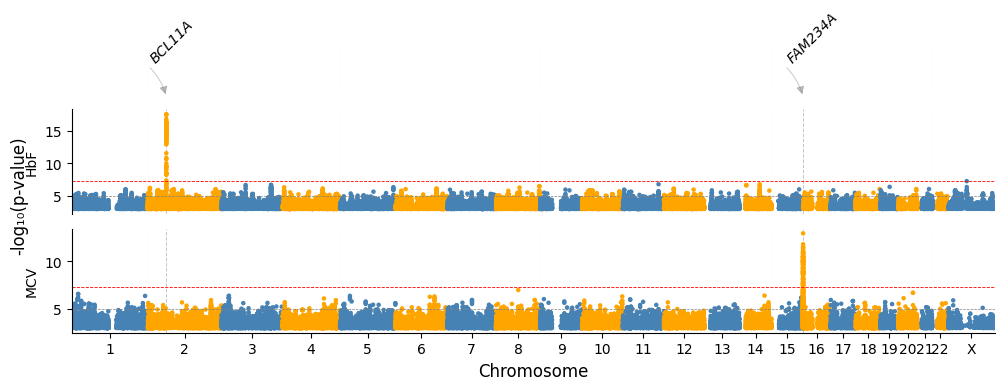

In [ ]:
fig, axes = plot_linear(
    sumstats_loaded=sumstats_loaded, 
    track_heights=[0.5,1,1], 
    hits_table=hits_table, 
    plot_title="test_pycmplot_python_api",
    label_col='top_gene', 
    output_format='png',
    dpi=300, chr_spacing=0.0,
    point_size=5,
    signif_lines=signif_lines,
    logp=True, colors=['steelblue','orange'], 
    figsize=(10, 4), 
    trim_pval=0.001
)

### Highlighting significant loci and annotating by SNP

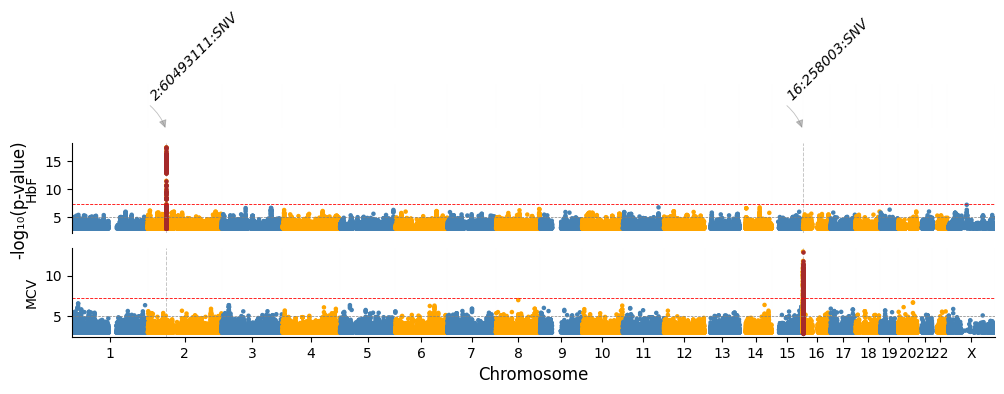

In [ ]:
fig, axes = plot_linear(
    sumstats_loaded=sumstats_loaded, 
    track_heights=[0.5,1,1], 
    hits_table=hits_table, 
    plot_title="test_pycmplot_python_api",
    label_col='SNP', 
    output_format='png',
    dpi=300, chr_spacing=0.0,
    point_size=5,
    signif_lines=signif_lines,
    highlight=True,
    logp=True, colors=['steelblue','orange'], 
    figsize=(10, 4), 
    trim_pval=0.001
)

### Highlighting by a different p-value threshold and changing plot colors and removing track labels

- Notice that a chrX locus is highlighted but not annotated. 

- This is because it did not meat the default significance threshold used in the data preparation function that generated the hits table.

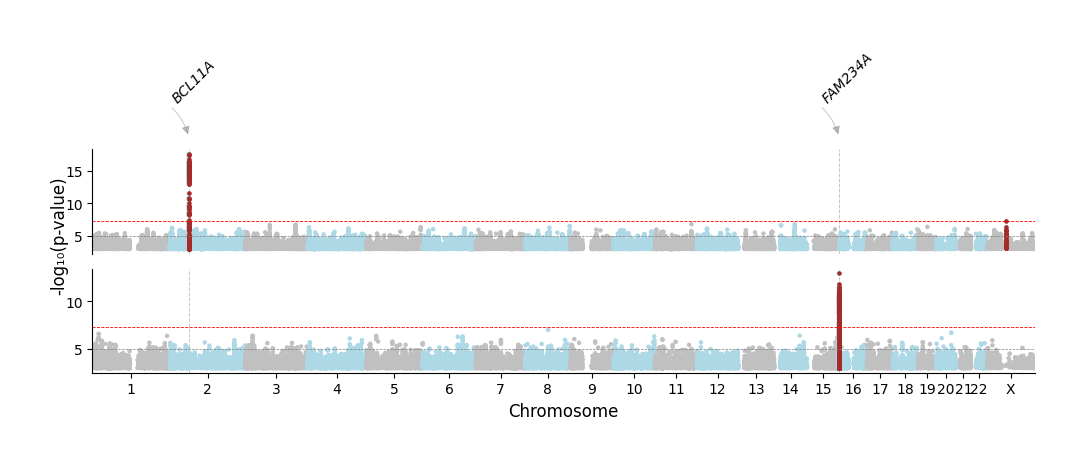

In [ ]:
fig, axes = plot_linear(
    sumstats_loaded=sumstats_loaded, 
    track_heights=[0.5,1,1],
    no_track_labels=True,
    hits_table=hits_table, 
    plot_title="test_pycmplot_python_api",
    label_col='nearest_upstream_gene', 
    output_format='png',
    dpi=300, chr_spacing=0.0,
    point_size=5,
    signif_lines=signif_lines,
    highlight=True,
    highlight_thresh=1e-7,
    logp=True, colors=['silver','lightblue'], 
    figsize=(10, 4), 
    trim_pval=0.001
)

## Generating circular plots

- Here, we specify gene annotation by the ```annotate``` argument.
- It takes either `SNP` or `GENE`. When `GENE` is specified, the `top_gene` column in the hits table will be used.

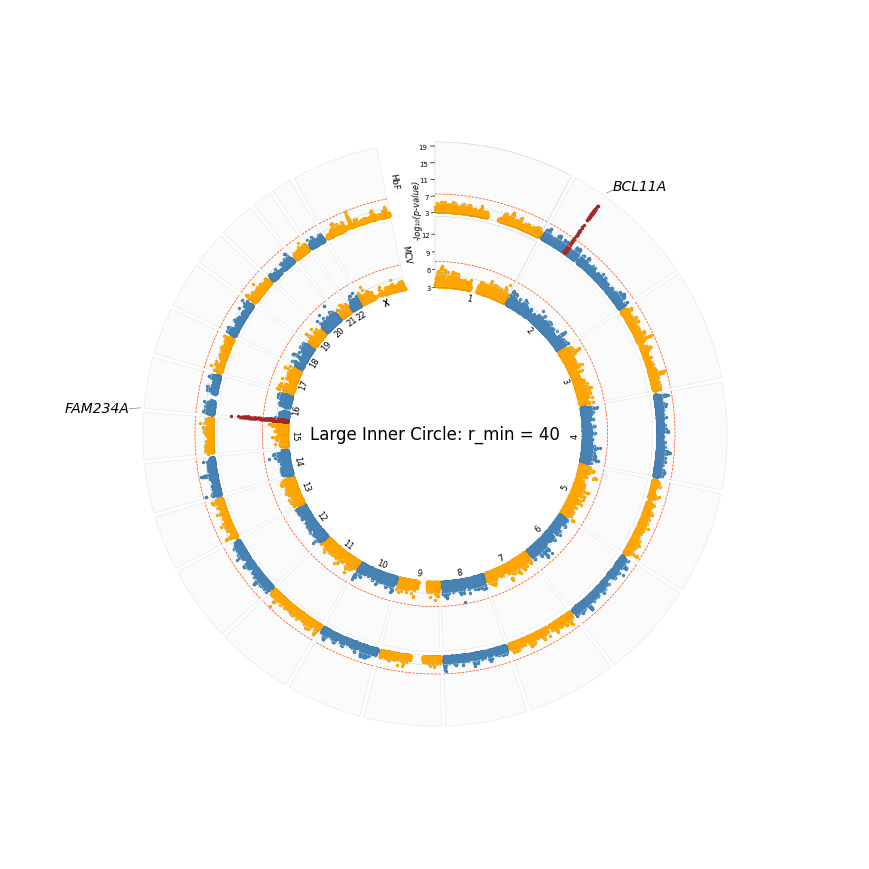

In [ ]:
fig = plot_circular(
    sumstats_loaded=sumstats_loaded,
    hits_table=hits_table,
    sector_sizes=merged_sector_sizes,
    annotate="GENE",
    plot_title="Large Inner Circle: r_min = 40",
    #label_col='top_gene', 
    output_format='png',
    annotation_size=10,
    dpi=300, 
    highlight=True,
    pad=1,
    r_min=40,
    r_max=100,
    signif_lines=signif_lines,
    logp=True, colors=['steelblue','orange'], 
    #figsize=(10, 4), 
)

### Controling the inner circle size

- The inner circle size is controled by the `r_min` (minimum radius) argument. It indicates the proportion of the figure the inner circle occupies.

- When dealing with a few sumstats, it should be appropriate to use a relatively high value so the tracks (Manhattan plots) a well represented.

- With many more sumstats, `r_min` should be lower. For instance, I have noticed that `r_min = 20` works well for >= 4 sumstats. 20 is thus the default when `r_min` is not set.

- The total size of the circle is also determined by `r_max` (maximum radius). It is recommended to always use the default of 100.

- For instance, we will use `r_min = 10` below so you see that the plot looks messy with 2 sumstats.

- We can control the size of the plot title using `plot_title_size`. However, anything fitted within that tiny space would not be visible.

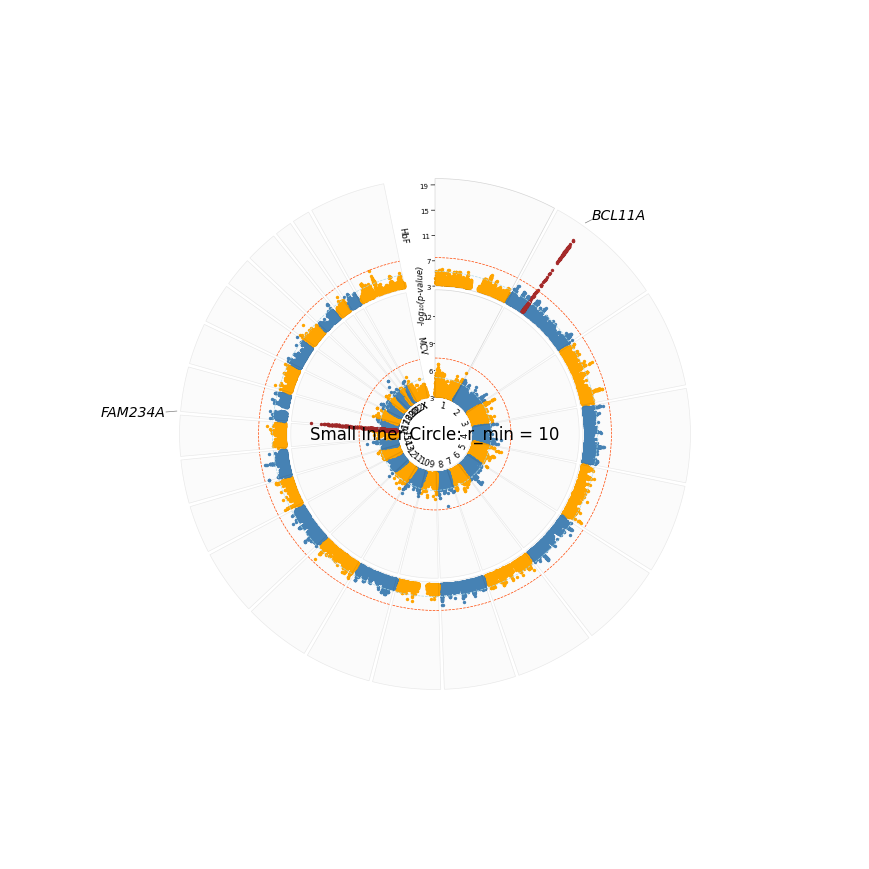

In [ ]:
fig = plot_circular(
    sumstats_loaded=sumstats_loaded,
    hits_table=hits_table,
    sector_sizes=merged_sector_sizes,
    annotate="GENE",
    plot_title="Small Inner Circle: r_min = 10",
    #label_col='top_gene', 
    output_format='png',
    annotation_size=10,
    dpi=300, 
    highlight=True,
    pad=1,
    r_min=10,
    r_max=100,
    signif_lines=signif_lines,
    logp=True, colors=['steelblue','orange'], 
    #figsize=(10, 4), 
)

#### We can make it look better by placing chrom labels outside, and excluding plot title and track labels

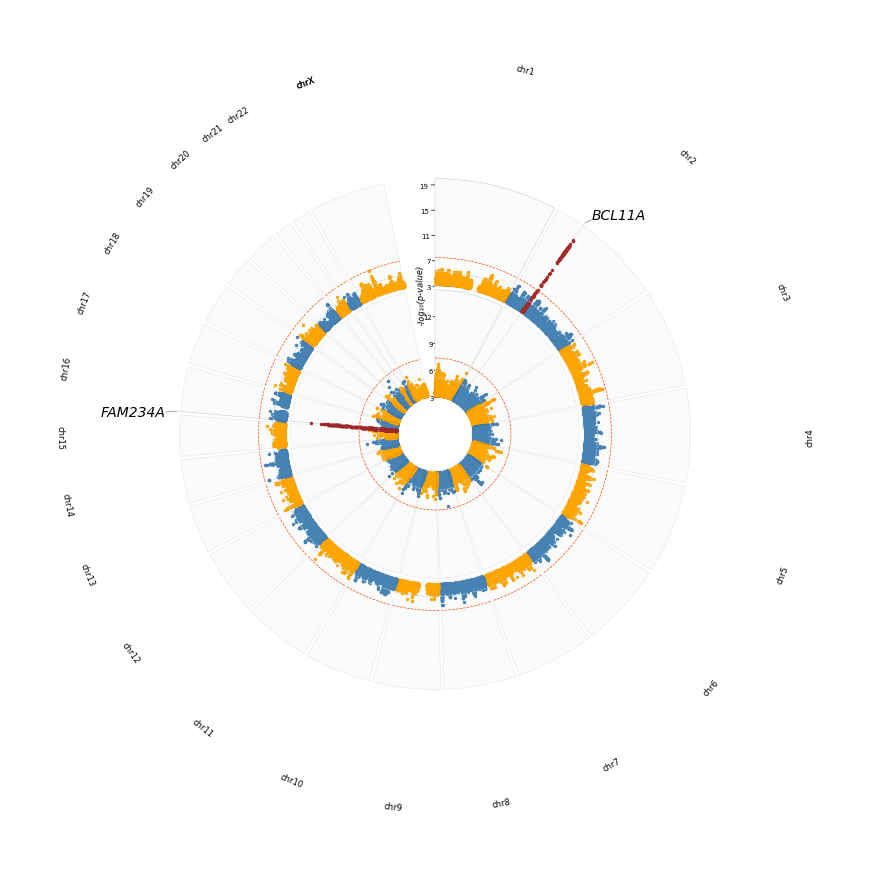

In [ ]:
fig = plot_circular(
    sumstats_loaded=sumstats_loaded,
    hits_table=hits_table,
    sector_sizes=merged_sector_sizes,
    annotate="GENE",
    #plot_title="test_pycmplot_python_api",
    chrom_label_side='outside',
    output_format='png',
    annotation_size=10,
    dpi=300, 
    highlight=True,
    highlight_line=True,
    no_track_labels=True,
    pad=1,
    r_min=10,
    r_max=100,
    signif_lines=signif_lines,
    logp=True, colors=['steelblue','orange'], 
    #figsize=(10, 4), 
)

#### SNP Annotation, highlight threshold and color change

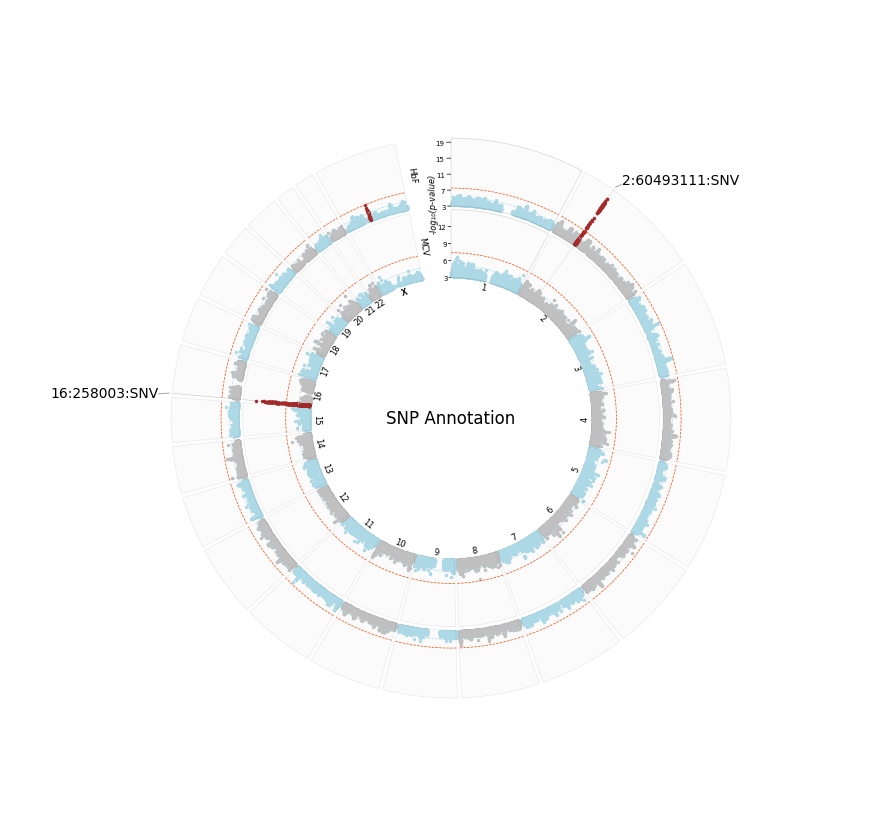

In [ ]:
fig = plot_circular(
    sumstats_loaded=sumstats_loaded,
    hits_table=hits_table,
    sector_sizes=merged_sector_sizes,
    annotate="SNP",
    plot_title="SNP Annotation",
    #label_col='top_gene', 
    output_format='png',
    annotation_size=10,
    dpi=300, 
    highlight=True,
    highlight_line=True, 
    highlight_thresh=1e-7,
    pad=1,
    r_min=40,
    r_max=100,
    signif_lines=signif_lines,
    logp=True, colors=['silver','lightblue'], 
    #figsize=(10, 4), 
)

## Ensuring all highlighted loci are also annotated

- We set the same `signif_threshold` and `highlight_thresh` values.

- Remember you can give these outputs any name: `merged_sector_sizes`, `sumstats_loaded`, `hits_table`, `signif_lines`

In [ ]:
pycmplot_dict = get_sumstats_and_merged_sector_list(
    sum_stats=sumstats_list,
    labels=labels_list, 
    file_info=sumstat_info_dict, 
    logp=True, 
    table_out="test_pycmplot_python_api", 
    trim_pval=0.001,
    signif_threshold=1e-7
)

merged_assoc_sector_sizes = pycmplot_dict["sectors"]
sumstats_loaded = pycmplot_dict["dfs"]
hits_table = pycmplot_dict["annot"]
signif_lines = pycmplot_dict["lines"]
pval_dict = pycmplot_dict["pvals"]

hits_table

,CHR,POS,SNP,P,BUILD,logP,LABEL,OLD_POS,OLD_BUILD,genic,...,promoter_upstream_flag,gene_density,top_gene,biotype,priority_score,distance,promoter_flag,distance_score,biotype_weight,promoter_bonus
1,2,60493111,2:60493111:SNV,3.039700e-18,hg38,17.517169,HbF,60493111,hg38,True,...,False,46.0,BCL11A,protein_coding,4.0,0,False,1.0,1.0,0.0
0,16,258003,16:258003:SNV,1.094200e-13,hg38,12.960903,MCV,258003,hg38,True,...,False,150.0,FAM234A,protein_coding,4.0,0,False,1.0,1.0,0.0
2,X,63094194,23:62313664:SNV,5.633700e-08,hg38,7.249206,HbF,62313664,hg19,False,...,False,NaN,SPIN4-ARHGEF9,intergenic,NaN,253034-540773,None,NaN,NaN,NaN


- **See that we now have three loci in the hits table**

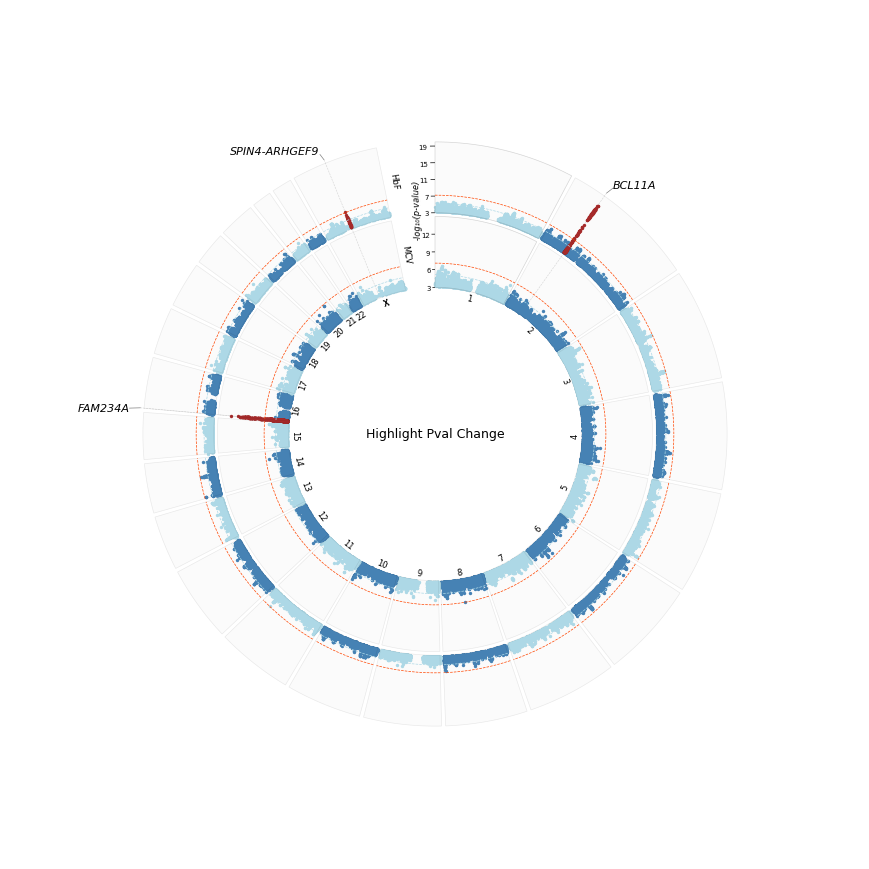

In [ ]:
fig1 = plot_circular(
    sumstats_loaded=sumstats_loaded,
    hits_table=hits_table,
    sector_sizes=merged_sector_sizes,
    annotate="GENE",
    plot_title="Highlight Pval Change",
    plot_title_size=9,
    #label_col='top_gene', 
    output_format='png',
    annotation_size=8,
    dpi=300, 
    highlight=True,
    highlight_thresh=1e-7,
    highlight_line=True,
    pad=1,
    r_min=40,
    r_max=100,
    signif_lines=signif_lines,
    logp=True, colors=['steelblue','lightblue'], 
    #figsize=(10, 4), 
)

### Explicitly speficying directory where output files should be stored

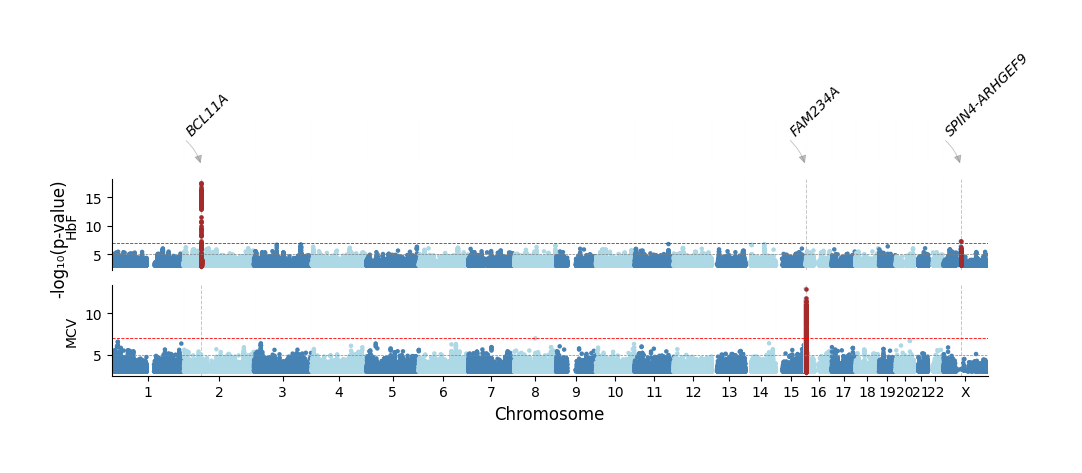

In [ ]:
fig2, axes = plot_linear(
    sumstats_loaded=sumstats_loaded, 
    track_heights=[0.5,1,1], 
    hits_table=hits_table, 
    plot_title="test_pycmplot_python_api",
    output_dir='/home/kesohku1/projects/gwas/', # <--- output directory
    label_col='top_gene', 
    output_format='png',
    dpi=300, chr_spacing=0.0,
    point_size=5,
    highlight=True,
    highlight_thresh=1e-7,
    signif_lines=signif_lines,
    logp=True, colors=['steelblue','lightblue'], 
    figsize=(10, 4), # (with, height)
    trim_pval=0.001
)

# Handling other use cases and QQ-plots

## Summary stats without **BUILD** column and no `build` information provided

In [3]:
# susmtats
sumstats_no_build_col_list = [
    "/data/awonkam1/kesoh/gwas/sitt/sumher/kgp/nHbF/kgp-r2-0.60-maf-0.01_nHbF_agecut-5_kvik1.step2.assoc.gz",
    "/data/awonkam1/kesoh/gwas/sitt/sumher/h3a/nMCV/h3a-r2-0.60-maf-0.01_nMCV_agecut-5_kvik1.step2.assoc.gz",
    "/data/awonkam1/kesoh/gwas/sitt/sumher/gmv2p1/nHb/gmv2p1-r2-0.60-maf-0.01_nHb_agecut-5_kvik1.step2.assoc.gz",
    "/data/awonkam1/kesoh/gwas/sitt/sumher/gmv2p2/nRBC/gmv2p2-r2-0.60-maf-0.01_nRBC_agecut-5_kvik1.step2.assoc.gz",
    "/data/awonkam1/kesoh/gwas/sitt/sumher/caapa/nHCT/caapa-r2-0.60-maf-0.01_nHCT_agecut-5_kvik1.step2.assoc.gz",
    "/data/awonkam1/kesoh/gwas/sitt/sumher/topmed/nMCH/topmed-r2-0.60-maf-0.01_nMCH_agecut-5_kvik1.step2.assoc.gz"
]

# labels, same order as sumstatst
label_list = [
    "HbF",
    "MCV",
    "Hb",
    "RBC",
    "HCT",
    "MCH"
]

In [4]:
sumstats_info_dict = prep_pycmplot_input_info(
    sum_stats=sumstats_no_build_col_list,
    labels=label_list
)

sumstats_info_dict

[WARNING] No build column or builds detected. Summary stats will be
        plotted in their respective coordinate systems.
        If your data are in different coordinate systems, putting them in one plot
        is not advisable, especially if ``--annotate`` is set!


{'HbF': [['Chromosome', 'Basepair', 'Predictor', 'Wald_P'],
  {'Chromosome': str, 'Basepair': int, 'Predictor': str, 'Wald_P': float},
  {'Chromosome': 'CHR', 'Basepair': 'POS', 'Predictor': 'SNP', 'Wald_P': 'P'},
  '\t'],
 'MCV': [['Chromosome', 'Basepair', 'Predictor', 'Wald_P'],
  {'Chromosome': str, 'Basepair': int, 'Predictor': str, 'Wald_P': float},
  {'Chromosome': 'CHR', 'Basepair': 'POS', 'Predictor': 'SNP', 'Wald_P': 'P'},
  '\t'],
 'Hb': [['Chromosome', 'Basepair', 'Predictor', 'Wald_P'],
  {'Chromosome': str, 'Basepair': int, 'Predictor': str, 'Wald_P': float},
  {'Chromosome': 'CHR', 'Basepair': 'POS', 'Predictor': 'SNP', 'Wald_P': 'P'},
  '\t'],
 'RBC': [['Chromosome', 'Basepair', 'Predictor', 'Wald_P'],
  {'Chromosome': str, 'Basepair': int, 'Predictor': str, 'Wald_P': float},
  {'Chromosome': 'CHR', 'Basepair': 'POS', 'Predictor': 'SNP', 'Wald_P': 'P'},
  '\t'],
 'HCT': [['Chromosome', 'Basepair', 'Predictor', 'Wald_P'],
  {'Chromosome': str, 'Basepair': int, 'Predictor

**NB: Note the warning about no build information**

Also notice that there is a mix of imputation panels in 'hg19' and 'hg38' build coordinates.

In [5]:
pycmplot_dict = get_sumstats_and_merged_sector_list(
    sum_stats=sumstats_no_build_col_list,
    labels=label_list, 
    file_info=sumstats_info_dict, 
    logp=True, 
    table_out="no_build_info", 
    trim_pval=0.001, 
    signif_threshold=1e-7
)

[INFO] Loading HbF from /data/awonkam1/kesoh/gwas/sitt/sumher/kgp/nHbF/kgp-r2-0.60-maf-0.01_nHbF_agecut-5_kvik1.step2.assoc.gz …
[INFO] Extracting raw p-values for QQ-plotting ...
[INFO] Excluding variants with p-value less than 0.001 to speed up Manhattan plotting ...
[INFO] Adding a 'logP' column ...
[INFO] Normalizing chromosome names {"23": "X", "24": "Y", "M": "MT", "MTDNA": "MT"} ...
[INFO] Extracting variants to highlight ...
[INFO] Loading RBC from /data/awonkam1/kesoh/gwas/sitt/sumher/gmv2p2/nRBC/gmv2p2-r2-0.60-maf-0.01_nRBC_agecut-5_kvik1.step2.assoc.gz …
[INFO] Extracting raw p-values for QQ-plotting ...
[INFO] Excluding variants with p-value less than 0.001 to speed up Manhattan plotting ...
[INFO] Adding a 'logP' column ...
[INFO] Normalizing chromosome names {"23": "X", "24": "Y", "M": "MT", "MTDNA": "MT"} ...
[INFO] Extracting variants to highlight ...
[INFO] Loading MCV from /data/awonkam1/kesoh/gwas/sitt/sumher/h3a/nMCV/h3a-r2-0.60-maf-0.01_nMCV_agecut-5_kvik1.step2.as

---

- Observe the `pycmplot_dict`

In [5]:
pycmplot_dict.keys()

dict_keys(['sectors', 'dfs', 'annot', 'lines', 'pvals'])

In [6]:
pycmplot_dict["sectors"]

{'1': [1310551, 248406983],
 '2': [0, 241760212],
 '3': [0, 197863134],
 '4': [0, 190705620],
 '5': [0, 181138716],
 '6': [0, 170746947],
 '7': [0, 159088708],
 '8': [0, 144656280],
 '9': [0, 140171117],
 '10': [0, 134955752],
 '11': [0, 135072575],
 '12': [0, 132758138],
 '13': [18076444, 114061271],
 '14': [19272226, 105539859],
 '15': [22400483, 101942574],
 '16': [0, 89820497],
 '17': [0, 83094852],
 '18': [0, 79785225],
 '19': [0, 58605740],
 '20': [0, 64276603],
 '21': [12853295, 48039473],
 '22': [15917910, 50704264],
 'X': [2556489, 154982868],
 'Spacer1': [0, 126973296]}

In [7]:
pycmplot_dict["dfs"].keys()

dict_keys(['HCT', 'Hb', 'HbF', 'MCH', 'MCV', 'RBC'])

In [8]:
pycmplot_dict["lines"]

[{'genome': 7.0, 'suggestive': 5.0},
 {'genome': 7.0, 'suggestive': 5.0},
 {'genome': 7.0, 'suggestive': 5.0},
 {'genome': 7.0, 'suggestive': 5.0},
 {'genome': 7.0, 'suggestive': 5.0},
 {'genome': 7.0, 'suggestive': 5.0}]

In [9]:
pycmplot_dict["pvals"]

{'HbF': array([0.80238 , 0.1593  , 0.70696 , ..., 0.10506 , 0.044299, 0.044299]),
 'MCV': array([0.43549 , 0.38235 , 0.23061 , ..., 0.24768 , 0.7078  , 0.015747]),
 'Hb': array([0.36697, 0.84087, 0.84771, ..., 0.91971, 0.7597 , 0.61939]),
 'RBC': array([0.46497, 0.10017, 0.34216, ..., 0.98986, 0.33426, 0.4835 ]),
 'HCT': array([0.66248, 0.96457, 0.79573, ..., 0.38697, 0.64664, 0.55925]),
 'MCH': array([0.94428, 0.96713, 0.86231, ..., 0.35127, 0.4025 , 0.38731])}

In [10]:
sectors_sizes = pycmplot_dict["sectors"]
sumstast_loaded = pycmplot_dict["dfs"]
annot_df = pycmplot_dict["annot"]
sig_lines = pycmplot_dict["lines"]
pval_dict = pycmplot_dict["pvals"]

In [11]:
annot_df

,CHR,SNP,POS,P,logP,LABEL
0,2,2:60721347,60721347,1.567800e-16,15.804709,HbF
5,16,16:258003:G:A,258003,1.094200e-13,12.960903,MCV


**Notice that there are only two significant variants in the table.**
- Is this a true reflection of the data?
- Or is this an artefact of lack of build information during annotation?

[INFO] Plotting : HCT
[INFO] Plotting : Hb
[INFO] Plotting : HbF
[INFO] Plotting : MCH
[INFO] Plotting : MCV
[INFO] Plotting : RBC
[INFO] 'SNP' column is used for annotation since 'top_gene' column could not be resolved in hits table.
[INFO] 'SNP' column is used for annotation since 'top_gene' column could not be resolved in hits table.
[INFO] Saved circular Manhattan plot: /home/kesohku1/projects/gwas/scripts/pycmplot/no_build_info_hct_hb_hbf_mch_mcv_rbc_cm_logp.png


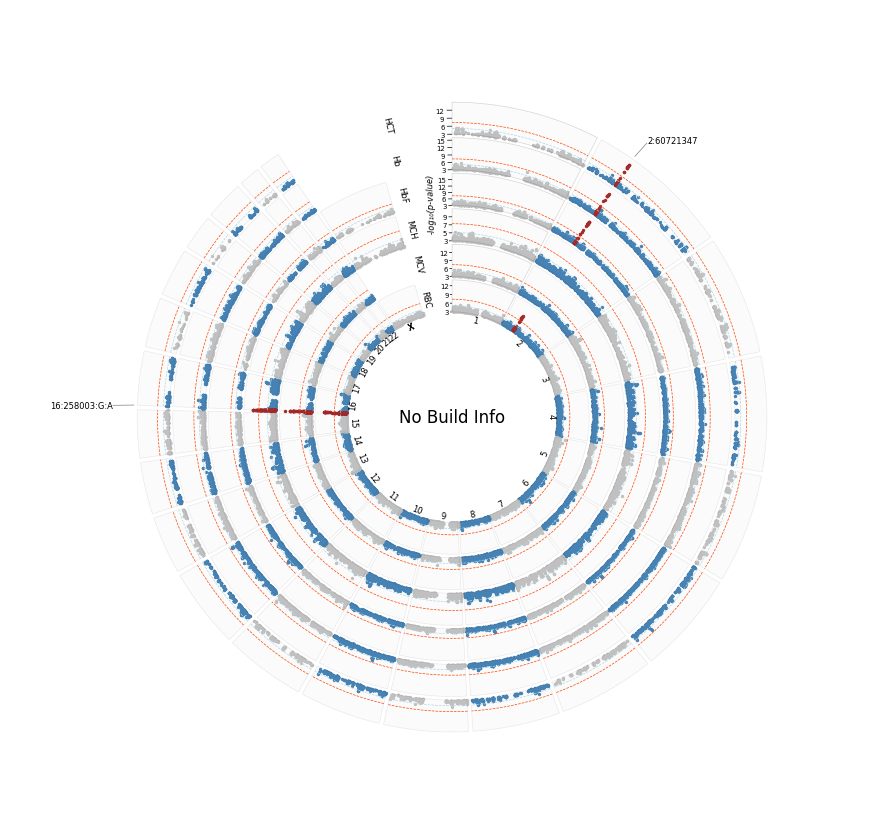

In [12]:
plot_circular(
    sumstats_loaded=sumstast_loaded, 
    sector_sizes=sectors_sizes,
    annotate='gene', # remember there was no build info hence hits table was not annotated with genes. Let's see plotting behaviour in this scenario
    label_col='top_gene',
    logp=True, 
    highlight=True, 
    hits_table=annot_df, 
    plot_title="No Build Info", 
    r_min=30
)

- `annotate` is set, `label_col` is set, but **annot_df** does not contain gene information. The package defaults to **'SNP'** column.

----

## Supplying builds with summary stats

In [2]:
# susmtats
sumstats_no_build_col_list = [
    "/data/awonkam1/kesoh/gwas/sitt/sumher/kgp/nHbF/kgp-r2-0.60-maf-0.01_nHbF_agecut-5_kvik1.step2.assoc.gz",
    "/data/awonkam1/kesoh/gwas/sitt/sumher/h3a/nMCV/h3a-r2-0.60-maf-0.01_nMCV_agecut-5_kvik1.step2.assoc.gz",
    "/data/awonkam1/kesoh/gwas/sitt/sumher/gmv2p1/nHb/gmv2p1-r2-0.60-maf-0.01_nHb_agecut-5_kvik1.step2.assoc.gz",
    "/data/awonkam1/kesoh/gwas/sitt/sumher/gmv2p2/nRBC/gmv2p2-r2-0.60-maf-0.01_nRBC_agecut-5_kvik1.step2.assoc.gz",
    "/data/awonkam1/kesoh/gwas/sitt/sumher/caapa/nHCT/caapa-r2-0.60-maf-0.01_nHCT_agecut-5_kvik1.step2.assoc.gz",
    "/data/awonkam1/kesoh/gwas/sitt/sumher/topmed/nMCH/topmed-r2-0.60-maf-0.01_nMCH_agecut-5_kvik1.step2.assoc.gz"
]

# labels, same order as sumstatst
label_list = [
    "HbF",
    "MCV",
    "Hb",
    "RBC",
    "HCT",
    "MCH"
]

# supplying sumstat builds, same order as sumstatst and labels
build_list = [
    "hg19",
    "hg38",
    "hg19",
    "hg38",
    "hg19",
    "hg38"
]

In [3]:
sumstats_info_dict = prep_pycmplot_input_info(
    sum_stats=sumstats_no_build_col_list,
    labels=label_list, 
    build_list=build_list
)

sumstats_info_dict

{'HbF': [['Chromosome', 'Basepair', 'Predictor', 'Wald_P'],
  {'Chromosome': str, 'Basepair': int, 'Predictor': str, 'Wald_P': float},
  {'Chromosome': 'CHR', 'Basepair': 'POS', 'Predictor': 'SNP', 'Wald_P': 'P'},
  '\t',
  'hg19'],
 'MCV': [['Chromosome', 'Basepair', 'Predictor', 'Wald_P'],
  {'Chromosome': str, 'Basepair': int, 'Predictor': str, 'Wald_P': float},
  {'Chromosome': 'CHR', 'Basepair': 'POS', 'Predictor': 'SNP', 'Wald_P': 'P'},
  '\t',
  'hg38'],
 'Hb': [['Chromosome', 'Basepair', 'Predictor', 'Wald_P'],
  {'Chromosome': str, 'Basepair': int, 'Predictor': str, 'Wald_P': float},
  {'Chromosome': 'CHR', 'Basepair': 'POS', 'Predictor': 'SNP', 'Wald_P': 'P'},
  '\t',
  'hg19'],
 'RBC': [['Chromosome', 'Basepair', 'Predictor', 'Wald_P'],
  {'Chromosome': str, 'Basepair': int, 'Predictor': str, 'Wald_P': float},
  {'Chromosome': 'CHR', 'Basepair': 'POS', 'Predictor': 'SNP', 'Wald_P': 'P'},
  '\t',
  'hg38'],
 'HCT': [['Chromosome', 'Basepair', 'Predictor', 'Wald_P'],
  {'Chrom

In [4]:
pycmplot_dict = get_sumstats_and_merged_sector_list(
    sum_stats=sumstats_no_build_col_list,
    labels=label_list, 
    file_info=sumstats_info_dict, 
    logp=True, 
    table_out="with_build_info", 
    trim_pval=0.001,
    signif_threshold=1e-7,
)

[INFO] Loading HbF from /data/awonkam1/kesoh/gwas/sitt/sumher/kgp/nHbF/kgp-r2-0.60-maf-0.01_nHbF_agecut-5_kvik1.step2.assoc.gz …
[INFO] Extracting raw p-values for QQ-plotting ...
[INFO] Excluding variants with p-value less than 0.001 to speed up Manhattan plotting ...
[INFO] Adding a 'logP' column ...
[INFO] Normalizing chromosome names {"23": "X", "24": "Y", "M": "MT", "MTDNA": "MT"} ...
[INFO] Converting hg19 coordinates to hg38 ...
[INFO] Loading LiftOver chain file: /home/kesohku1/projects/gwas/scripts/pycmplot/pycmplot/data/hg19ToHg38.over.chain
[INFO] Extracting variants to highlight ...
[INFO] Loading Hb from /data/awonkam1/kesoh/gwas/sitt/sumher/gmv2p1/nHb/gmv2p1-r2-0.60-maf-0.01_nHb_agecut-5_kvik1.step2.assoc.gz …
[INFO] Extracting raw p-values for QQ-plotting ...
[INFO] Excluding variants with p-value less than 0.001 to speed up Manhattan plotting ...
[INFO] Adding a 'logP' column ...
[INFO] Normalizing chromosome names {"23": "X", "24": "Y", "M": "MT", "MTDNA": "MT"} ...
[I

In [5]:
sectors_sizes = pycmplot_dict["sectors"]
sumstast_loaded = pycmplot_dict["dfs"]
annot_df = pycmplot_dict["annot"]
sig_lines = pycmplot_dict["lines"]
pval_dict = pycmplot_dict["pvals"]

In [10]:
annot_df

,CHR,SNP,POS,P,BUILD,logP,LABEL,OLD_POS,OLD_BUILD,genic,...,promoter_upstream_flag,gene_density,top_gene,biotype,priority_score,distance,promoter_flag,distance_score,biotype_weight,promoter_bonus
0,2,2:60721347,60494212,1.567800e-16,hg38,15.804709,HbF,60721347.0,hg19,True,...,False,46,BCL11A,protein_coding,4.0,0,False,1.0,1.0,0.0
3,16,16:258003:G:A,258003,1.094200e-13,hg38,12.960903,MCV,NaN,NaN,True,...,False,150,FAM234A,protein_coding,4.0,0,False,1.0,1.0,0.0


In [9]:
sumstast_loaded.keys()

dict_keys(['HbF', 'MCV', 'Hb', 'RBC', 'HCT', 'MCH'])

[INFO] Plotting : HbF
[INFO] Plotting : MCV
[INFO] Plotting : Hb
[INFO] Plotting : RBC
[INFO] Plotting : HCT
[INFO] Plotting : MCH
[INFO] Saved circular Manhattan plot: /home/kesohku1/projects/gwas/scripts/pycmplot/with_build_info_hbf_mcv_hb_rbc_hct_mch_cm_logp.png


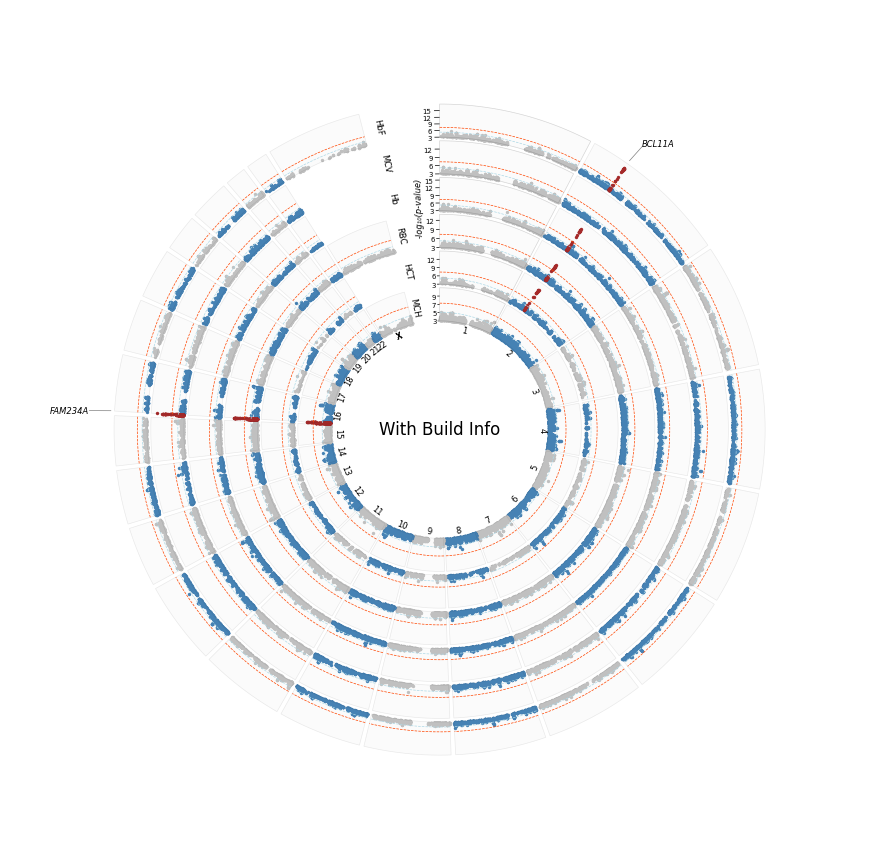

In [11]:
plot_circular(
    sumstats_loaded=sumstast_loaded, 
    sector_sizes=sectors_sizes,
    annotate='gene', # remember there was no build info hence hits table was not annotated with genes. Let's see plotting behaviour in this scenario
    label_col='top_gene',
    logp=True, 
    highlight=True, 
    hits_table=annot_df, 
    plot_title="With Build Info", 
    r_min=30
)

----

## QQ-Plotting

### Overlaying multiple
 - Use `thin` to speed up plotting. Otherwise, using all variants is extremely slow.
 - By setting `thin_below`, you apply thinning to only variants with p-value >= the value set.
   That is near the null base.

In [6]:
pval_dict

{'HbF': array([0.80238 , 0.1593  , 0.70696 , ..., 0.10506 , 0.044299, 0.044299]),
 'MCV': array([0.43549 , 0.38235 , 0.23061 , ..., 0.24768 , 0.7078  , 0.015747]),
 'Hb': array([0.36697, 0.84087, 0.84771, ..., 0.91971, 0.7597 , 0.61939]),
 'RBC': array([0.46497, 0.10017, 0.34216, ..., 0.98986, 0.33426, 0.4835 ]),
 'HCT': array([0.66248, 0.96457, 0.79573, ..., 0.38697, 0.64664, 0.55925]),
 'MCH': array([0.94428, 0.96713, 0.86231, ..., 0.35127, 0.4025 , 0.38731])}

[INFO] Saved combined QQ plot: None.png


(<Figure size 600x600 with 1 Axes>,
 <Axes: xlabel='Expected −log₁₀(p)', ylabel='Observed −log₁₀(p)'>)

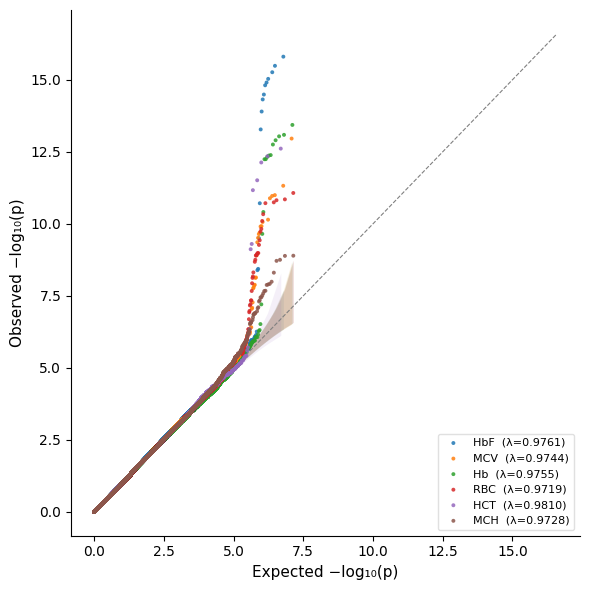

In [7]:
plot_qq_overlay(pval_dict=pval_dict, thin=True, thin_below=0.001)

### Separate qq-plots saved in separate figures
- As 'png' and 'pdf'

In [11]:
# png
plot_qq_separate(
    pval_dict=pval_dict, 
    thin=True, 
    thin_below=0.001, 
    output_path="/home/kesohku1/projects/gwas/scripts/figs/",
    base_name="test",
)

# pdf rasterized: low memory
plot_qq_separate(
    pval_dict=pval_dict, 
    thin=True, 
    thin_below=0.001, 
    output_path="/home/kesohku1/projects/gwas/scripts/figs/",
    base_name="test_rasterized",
    fig_format='pdf',
    rasterized=True,
)

# pdf not rasterized: higher memory
plot_qq_separate(
    pval_dict=pval_dict, 
    thin=True, 
    thin_below=0.001, 
    output_path="/home/kesohku1/projects/gwas/scripts/figs/",
    base_name="test_not_rasterized",
    fig_format='pdf',
    rasterized=False,
)

[INFO] Saved QQ plot: /home/kesohku1/projects/gwas/scripts/figs/test_HbF_MCV_Hb_RBC_HCT_MCH_qq_pval_HbF.png
[INFO] Saved QQ plot: /home/kesohku1/projects/gwas/scripts/figs/test_HbF_MCV_Hb_RBC_HCT_MCH_qq_pval_MCV.png
[INFO] Saved QQ plot: /home/kesohku1/projects/gwas/scripts/figs/test_HbF_MCV_Hb_RBC_HCT_MCH_qq_pval_Hb.png
[INFO] Saved QQ plot: /home/kesohku1/projects/gwas/scripts/figs/test_HbF_MCV_Hb_RBC_HCT_MCH_qq_pval_RBC.png
[INFO] Saved QQ plot: /home/kesohku1/projects/gwas/scripts/figs/test_HbF_MCV_Hb_RBC_HCT_MCH_qq_pval_HCT.png
[INFO] Saved QQ plot: /home/kesohku1/projects/gwas/scripts/figs/test_HbF_MCV_Hb_RBC_HCT_MCH_qq_pval_MCH.png
[INFO] Saved QQ plot: /home/kesohku1/projects/gwas/scripts/figs/testrasterized_HbF_MCV_Hb_RBC_HCT_MCH_qq_pval_HbF.pdf
[INFO] Saved QQ plot: /home/kesohku1/projects/gwas/scripts/figs/testrasterized_HbF_MCV_Hb_RBC_HCT_MCH_qq_pval_MCV.pdf
[INFO] Saved QQ plot: /home/kesohku1/projects/gwas/scripts/figs/testrasterized_HbF_MCV_Hb_RBC_HCT_MCH_qq_pval_Hb.pdf


['/home/kesohku1/projects/gwas/scripts/figs/testnotrasterized_HbF_MCV_Hb_RBC_HCT_MCH_qq_pval_HbF.pdf',
 '/home/kesohku1/projects/gwas/scripts/figs/testnotrasterized_HbF_MCV_Hb_RBC_HCT_MCH_qq_pval_MCV.pdf',
 '/home/kesohku1/projects/gwas/scripts/figs/testnotrasterized_HbF_MCV_Hb_RBC_HCT_MCH_qq_pval_Hb.pdf',
 '/home/kesohku1/projects/gwas/scripts/figs/testnotrasterized_HbF_MCV_Hb_RBC_HCT_MCH_qq_pval_RBC.pdf',
 '/home/kesohku1/projects/gwas/scripts/figs/testnotrasterized_HbF_MCV_Hb_RBC_HCT_MCH_qq_pval_HCT.pdf',
 '/home/kesohku1/projects/gwas/scripts/figs/testnotrasterized_HbF_MCV_Hb_RBC_HCT_MCH_qq_pval_MCH.pdf']

### Combined multi-panel

(<Figure size 1350x900 with 6 Axes>,
 [<Axes: title={'center': 'HbF'}, xlabel='Expected −log₁₀(p)', ylabel='Observed −log₁₀(p)'>,
  <Axes: title={'center': 'MCV'}, xlabel='Expected −log₁₀(p)', ylabel='Observed −log₁₀(p)'>,
  <Axes: title={'center': 'Hb'}, xlabel='Expected −log₁₀(p)', ylabel='Observed −log₁₀(p)'>,
  <Axes: title={'center': 'RBC'}, xlabel='Expected −log₁₀(p)', ylabel='Observed −log₁₀(p)'>,
  <Axes: title={'center': 'HCT'}, xlabel='Expected −log₁₀(p)', ylabel='Observed −log₁₀(p)'>,
  <Axes: title={'center': 'MCH'}, xlabel='Expected −log₁₀(p)', ylabel='Observed −log₁₀(p)'>])

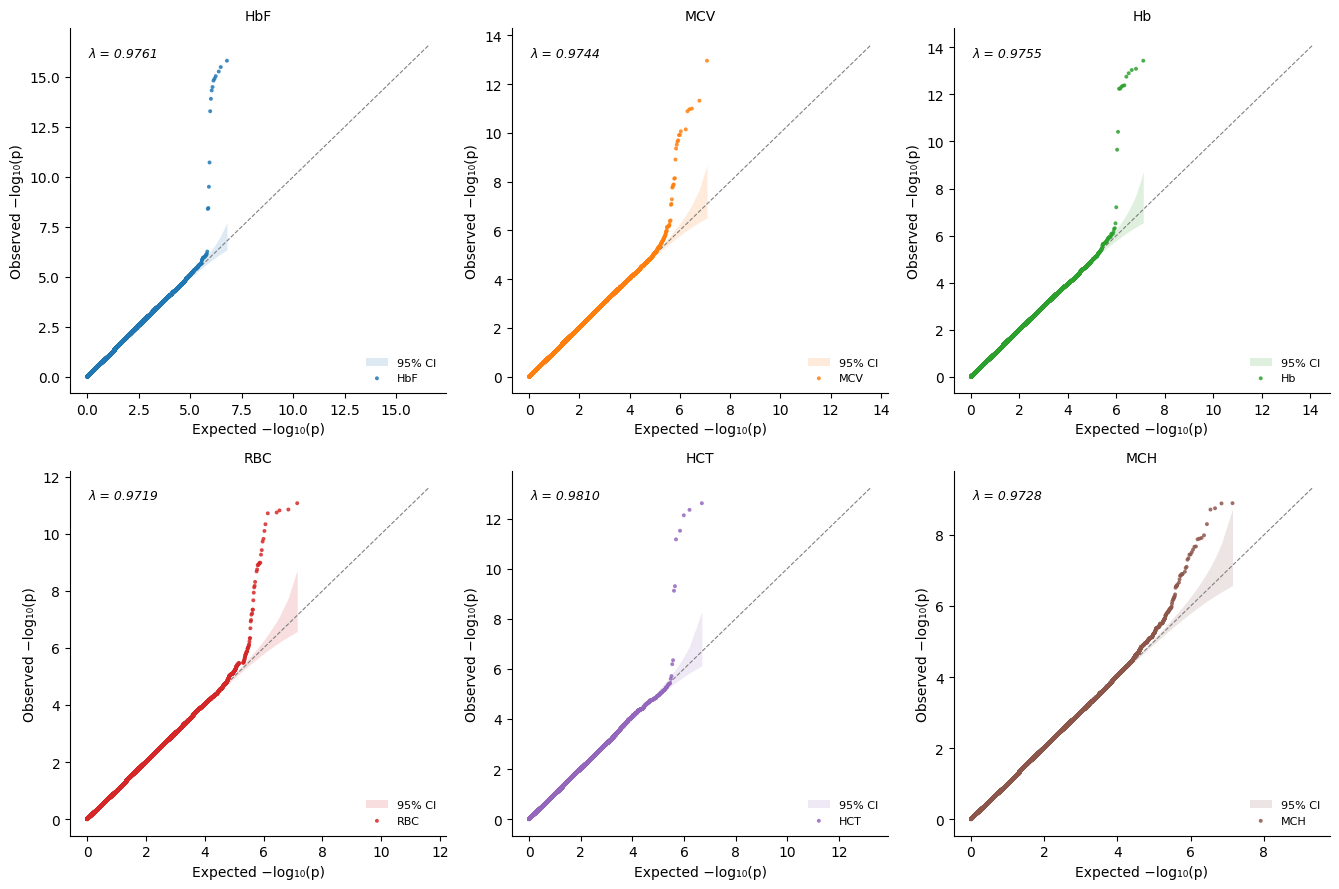

In [12]:
plot_qq_combined(pval_dict=pval_dict, thin=True, thin_below=0.001)

#### Customizing the grid arrangement
 - Use `ncols` (number of columns)

(<Figure size 900x1350 with 6 Axes>,
 [<Axes: title={'center': 'HbF'}, xlabel='Expected −log₁₀(p)', ylabel='Observed −log₁₀(p)'>,
  <Axes: title={'center': 'MCV'}, xlabel='Expected −log₁₀(p)', ylabel='Observed −log₁₀(p)'>,
  <Axes: title={'center': 'Hb'}, xlabel='Expected −log₁₀(p)', ylabel='Observed −log₁₀(p)'>,
  <Axes: title={'center': 'RBC'}, xlabel='Expected −log₁₀(p)', ylabel='Observed −log₁₀(p)'>,
  <Axes: title={'center': 'HCT'}, xlabel='Expected −log₁₀(p)', ylabel='Observed −log₁₀(p)'>,
  <Axes: title={'center': 'MCH'}, xlabel='Expected −log₁₀(p)', ylabel='Observed −log₁₀(p)'>])

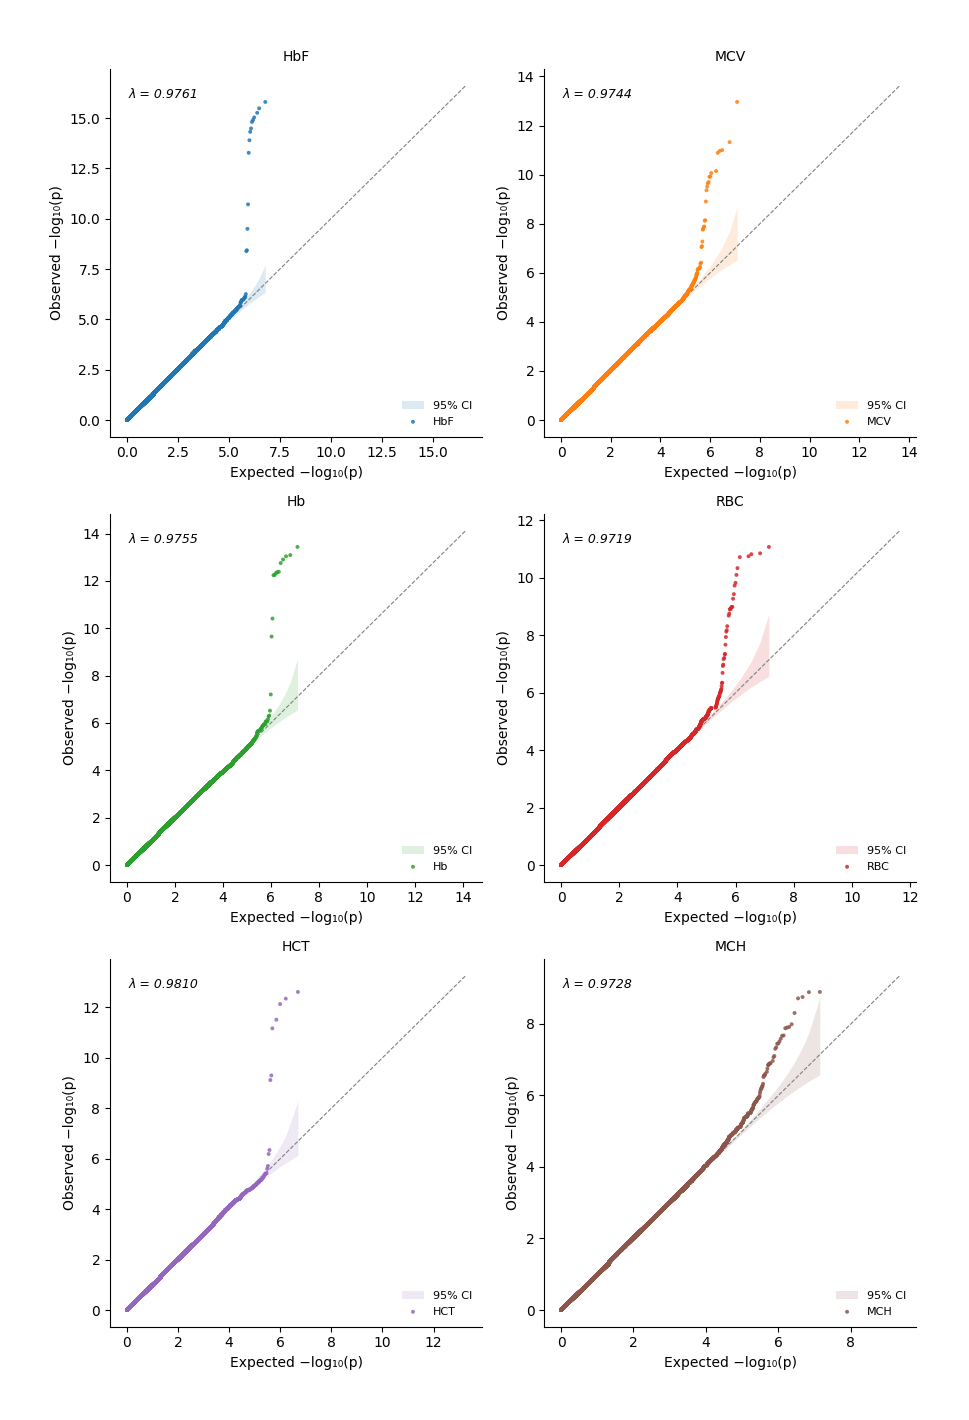

In [41]:
plot_qq_combined(pval_dict=pval_dict, thin=True, thin_below=0.001, ncols=2)

### Flexible handling of each qq-plot using the base `plot_qq_single` function directly
- Define your own axes
- Pass them to `ax` parameter

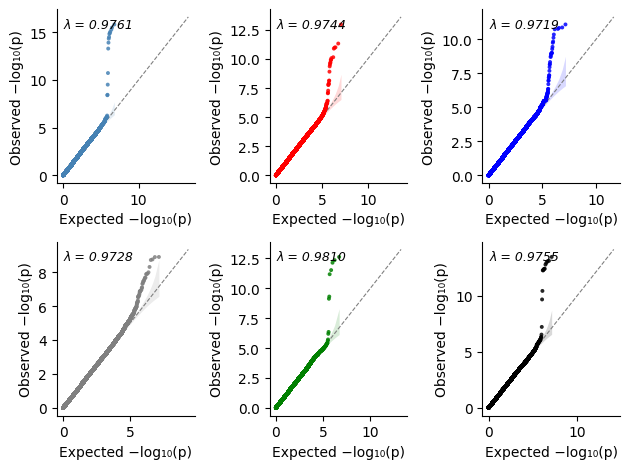

In [13]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2,3, squeeze=False)

plot_qq_single(thin=True, thin_below=0.001, pvals=pval_dict["HbF"], ax=axs[0][0], ci=0.95, show_lambda=True)
plot_qq_single(thin=True, thin_below=0.001, pvals=pval_dict["MCV"], ax=axs[0][1], ci=0.95, show_lambda=True, color="red")
plot_qq_single(thin=True, thin_below=0.001, pvals=pval_dict["RBC"], ax=axs[0][2], ci=0.95, show_lambda=True, color="blue")
plot_qq_single(thin=True, thin_below=0.001, pvals=pval_dict["MCH"], ax=axs[1][0], ci=0.95, show_lambda=True, color="grey")
plot_qq_single(thin=True, thin_below=0.001, pvals=pval_dict["HCT"], ax=axs[1][1], ci=0.95, show_lambda=True, color="green")
plot_qq_single(thin=True, thin_below=0.001, pvals=pval_dict["Hb"], ax=axs[1][2], ci=0.95, show_lambda=True, color="black")

plt.tight_layout()

### Or overlay them by simply using the same axis

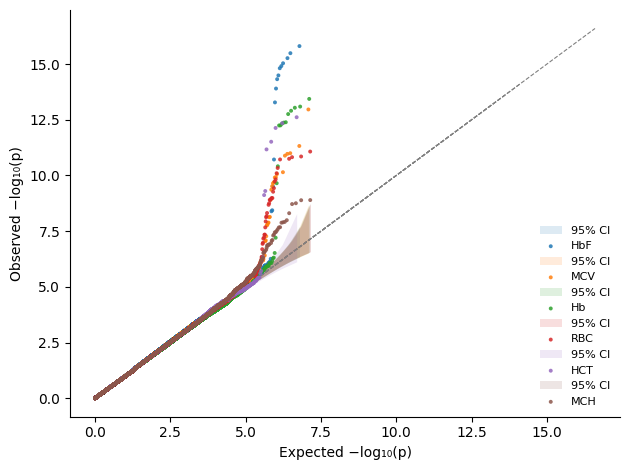

In [22]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# We will need separate colors for the sumstats
labels = pval_dict.keys()
n = len(labels)
cmap = plt.get_cmap("tab10")
colors = [mcolors.to_hex(cmap(i % 10)) for i in range(n)]

fig, axs = plt.subplots()

for label, color in zip(labels, colors):
    plot_qq_single(
        thin=True, 
        thin_below=0.001, 
        pvals=pval_dict[label], 
        ax=axs, 
        ci=0.95, 
        label=label, 
        color=color,
        show_lambda=False, # However, `plot_qq_overlay` and `plot_qq_combined` handle `show_lambda` better.
    )
    
plt.tight_layout()

### This gives us the flexibility to place multiple overlay plots on one figure

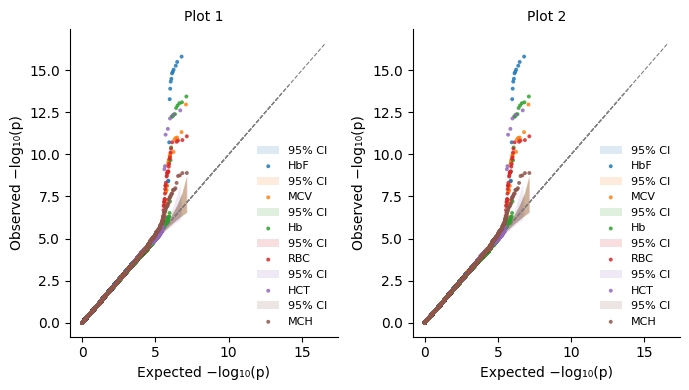

In [28]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# We will need separate colors for the sumstats
labels = pval_dict.keys()
n = len(labels)
cmap = plt.get_cmap("tab10")
colors = [mcolors.to_hex(cmap(i % 10)) for i in range(n)]

fig, axs = plt.subplots(1, 2, squeeze=False, figsize=(7,4))

for label, color in zip(labels, colors):
    plot_qq_single(
        thin=True, 
        thin_below=0.001, 
        pvals=pval_dict[label], 
        ax=axs[0][0], 
        ci=0.95, 
        label=label, 
        color=color,
        title="Plot 1",
        show_lambda=False, # However, `plot_qq_overlay` and `plot_qq_combined` handle `show_lambda` better.
    )

for label, color in zip(labels, colors):
    plot_qq_single(
        thin=True, 
        thin_below=0.001, 
        pvals=pval_dict[label], 
        ax=axs[0][1], 
        ci=0.95, 
        label=label, 
        color=color,
        title="Plot 2",        
        show_lambda=False, # However, `plot_qq_overlay` and `plot_qq_combined` handle `show_lambda` better.
    )    
plt.tight_layout()

----

# Final Notes

- The `prep_pycmplot_input_info` function saves the hits table as a TAB delimited file (.tsv) with the plot title provided combined with the labels and type of plot (lm or cm).

- If plot title is not provided, the function generates a random string for the file name and plot name.

- All files are saved in the user provided output directory using `output_dir`. If not provided, the current directory `'.'` is used.